## Loading packages

In [1]:
import sys
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings
import os

sys.path.append("../")

warnings.filterwarnings("ignore")

# os.environ["R_HOME"] = "/home/lxx/.conda/envs/r4Base/lib/R"
# os.environ["R_USER"] = "/home/lxx/.local/lib/python3.9/site-packages/rpy2"

import spCLUE

spCLUE.fix_seed(0)

## Loading data

In [2]:
sample_name="151673"
n_clusters = 5 if sample_name in [str(151669 + x) for x in range(4)] else 7
data_dir  = '/home/pxy/home/pxy/data/DLPFC/st/'

# data_file = f"../dataset/DLPFC/{sample_name}.h5ad"
# adata = sc.read_h5ad(data_file)
adata = sc.read_visium(data_dir + sample_name)
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


In [3]:
import pandas as pd

meta = pd.read_csv(
    data_dir+sample_name+"/metadata.tsv",
    sep="\t"
)

meta = meta.set_index("barcode")
adata.obs["Region"] = meta.loc[
    adata.obs_names,
    "layer_guess_reordered"
]
print(adata.obs["Region"].value_counts())
print("NA spots:", adata.obs["Region"].isna().sum())


Region
Layer3    989
Layer6    692
Layer5    673
WM        513
Layer1    273
Layer2    253
Layer4    218
Name: count, dtype: int64
NA spots: 28


In [4]:
# adata = spCLUE.preprocess(adata)
# adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
# g_spatia = spCLUE.prepare_graph(adata, "spatial")
# g_expr = spCLUE.prepare_graph(adata, "expr")
# graph_dict = {"spatial": g_spatia, "expr":g_expr}

In [5]:
# from spCLUE.preprocess import prepare_raw_counts_for_reconstruction
adata =spCLUE.preprocess(adata,n_top_genes=2000)
adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
g_spatia = spCLUE.prepare_graph(adata, "spatial")
g_expr = spCLUE.prepare_graph(adata, "expr")
graph_dict = {"spatial": g_spatia, "expr":g_expr}


预处理单切片数据 (全基因 PCA + 归一化 HVG)



根据原始计数挑选 top 2000 个高变基因...
全量数据归一化 (target_sum=1e4) & Log1p...
  ✓ 已保存归一化后的 HVG 重构目标: (3639, 2000)
将全量稀疏矩阵转换为稠密矩阵以计算 PCA...
计算 PCA (基于全基因归一化数据, n_components=200)...

✅ 预处理完成！
  - adata.X (全量归一化): (3639, 21842)
  - adata.obsm['X_hvg'] (归一化HVG): (3639, 2000)
  - adata.obsm['X_pca'] (全基因PCA): (3639, 200)

构建 spatial 图...
  - 使用空间坐标: (3639, 2)
  ✓ 空间图构建完成:  (3639, 3639), 边数=37726

构建 expr 图...
  - 使用PCA:  (3639, 200)
  ✓ 表达图构建完成: (3639, 3639), 边数=71452


## train spCLUE

In [6]:
spCLUE_model = spCLUE.spCLUE(
    input_data=adata.obsm['X_pca'],
    hvg_input=adata.obsm['X_pca'],
    graph_dict=graph_dict,
    n_clusters=7,
    n_hvgs=200,
    reconstruction_loss='mse',
    gamma=1.0,
    gamma_mask=0.5,
    beta=1.0,
    kappa=5.0,
    # cluster_weight_strategy='min',  # 🔥 置信度策略
    # cluster_warmup_epochs=50,       # 🔥 Warmup
    # dim_input=2000,
    # dim_hidden=256,
    # dim_embed=64,
    epochs = 800,
    patience=50,
    min_delta=0.005,
)
_, adata.obsm["spCLUE"] = spCLUE_model.train()

ℹ️ 初始化单切片模型 (CCGCN)
   - 输入:  200维PCA
   - 重构: 200个HVG
✅ 使用 MSE 重构损失
Training Start =========================>
重构损失类型: MSE
聚类对齐策略: min
Warmup epochs: 50
早停策略: patience=50, min_delta=0.005
损失权重: kappa=5.0, beta=1.0, gamma=1.0


  1%|          | 7/800 [00:01<01:46,  7.44it/s]


Epoch 1:   Loss=nan, ARI=0.018
 Cluster=2.5822, Recon=2.5083, MaskRecon=12.7772, LocalAgg=0.0000, Contrast=nan
  ClusterLoss=2.5636, NegLoss=0.0186


  6%|▌         | 49/800 [00:01<00:30, 24.68it/s]


Epoch 50:   Loss=nan, ARI=1.000
 Cluster=nan, Recon=nan, MaskRecon=nan, LocalAgg=0.0000, Contrast=nan
  ClusterLoss=nan, NegLoss=nan

Early stopping at epoch 50
Best loss: inf
Training Finished =================<


In [7]:
print(adata.obsm["spCLUE"].shape)


(3639, 24)


In [8]:
refinement = True
cluster_method = "mclust"
pred = spCLUE.clustering(
    adata,
    n_clusters,
    key="spCLUE",
    refinement=refinement,
    cluster_methods=cluster_method,
)

RuntimeError: mclust failed
===== R STDOUT =====

===== R STDERR =====
Error in if (G[1] == 1) { : missing value where TRUE/FALSE needed
Calls: Mclust -> eval -> eval -> mclustBIC
Execution halted


In [ ]:
print(adata.obs.columns)

Index(['in_tissue', 'array_row', 'array_col', 'Region', 'mclust',
       'mclust_refined'],
      dtype='object')


In [ ]:
adata = adata[adata.obs.Region.notna()]
ARI = adjusted_rand_score(adata.obs["Region"], adata.obs["mclust_refined"])
print(f"ARI on {sample_name}: {ARI}")

ARI on 151673: 0.40682060672483394


## visualization

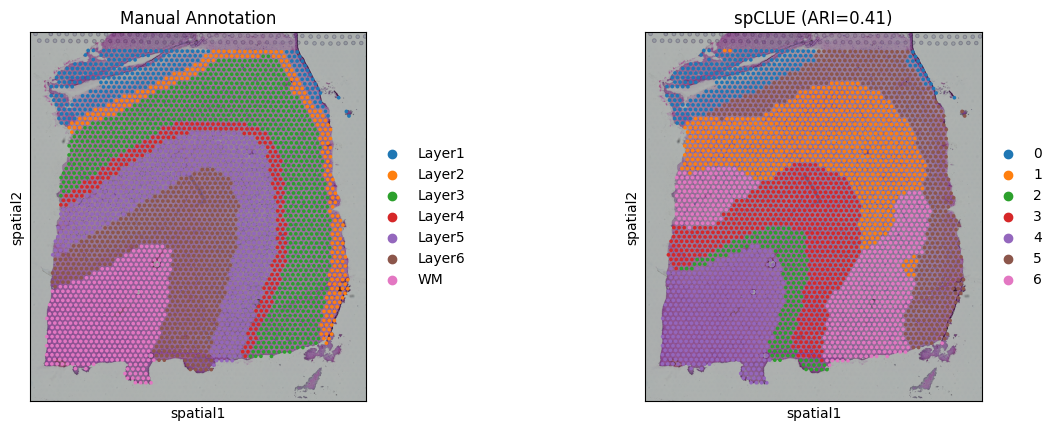

In [ ]:
adata.obs["spCLUE"] = adata.obs["mclust_refined"]
sc.pl.spatial(adata, color=["Region", "spCLUE"], title=["Manual Annotation", f"spCLUE (ARI={round(ARI, 2)})"])

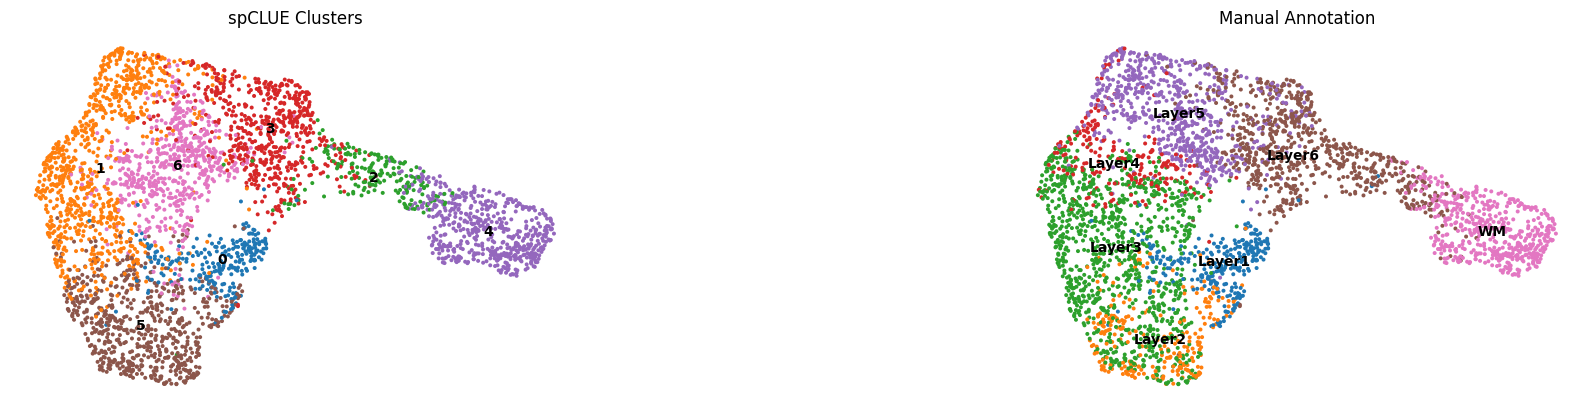

In [ ]:
# 1. 计算邻居图（如果尚未计算）
# 如果已计算过可跳过此步
sc.pp.neighbors(adata, use_rep="spCLUE", metric="cosine")

# 2. 计算UMAP嵌入
sc.tl.umap(adata)

# 3. 可视化UMAP，按spCLUE聚类结果着色
sc.pl.umap(
    adata,
    color=["spCLUE", "Region"],  # 同时显示聚类结果和手动注释进行对比
    title=["spCLUE Clusters", "Manual Annotation"],
    frameon=False,
    wspace=0.6,  # 调整子图间距
    legend_loc="on data",
    # save="spCLUE_umap.pdf"  # 可选：自动保存图像
)

# 4. （可选）显示聚类簇编号在图上
# sc.pl.umap(
#     adata,
#     color="spCLUE",
#     title=f"spCLUE UMAP (ARI={round(ARI, 2)})",
#     legend_loc="on data",
#     add_outline=True,
#     outline_width=0.01
# )